In [1]:
# Load in packages
import pandas as pd
import os

# Create a file path to the data
fp = os.path.join('..','data','wetlands_seasonal_bird_diversity.csv')
fp

# Read in the file
df = pd.read_csv(fp)

# Check the first 5 rows
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


<Axes: >

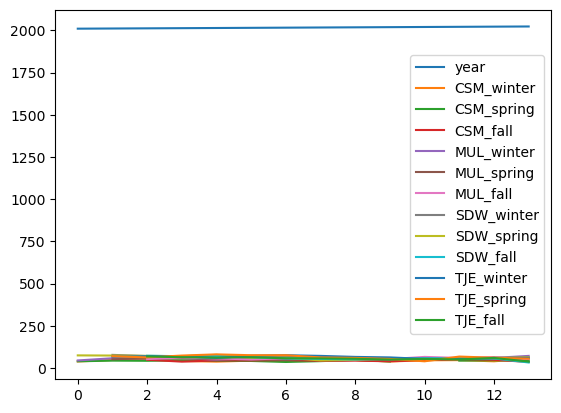

In [2]:
# Default plot(): one line plot per column with numeric data
df.plot()

Below is the general syntax for making a line plot of one column against another:
`df.plot(x='x_values_column', y='y_values_column')`

<Axes: xlabel='year'>

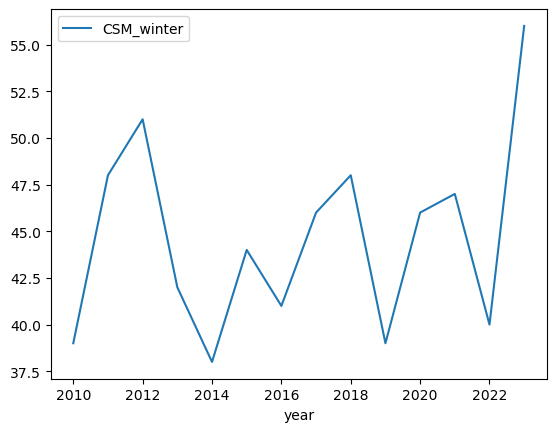

In [3]:
# Bird species registered during winter at CSM yearly
df.plot(x='year', y='CSM_winter')

Basic customizations specifying other parameters of the `plot()` method: 
`title`: title to use for the plot
`xlabel`: name to use for the x-label on x-axis
`y-label`: name to use for the y-label on the y-axis
`color`: change the color of our plot
`legend`: boolean value TRUE or FALSE. TRUE(default) includes the legend, FALSE removes the legend 
    NOTE: `legend` is the only one of these that does not go in '' because it is a value, whereas the others are text.

<Axes: title={'center': 'Bird species registered during winter at Carpinteria Salt Marsh'}, xlabel='Year', ylabel='Number of bird species'>

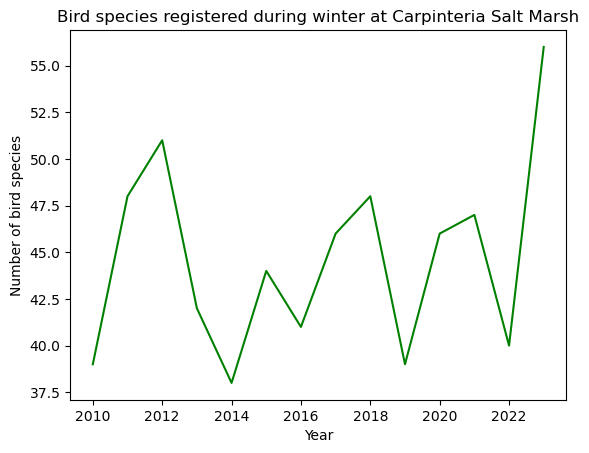

In [4]:
# For example:
df.plot(
    x='year',
    y='CSM_winter',
    title='Bird species registered during winter at Carpinteria Salt Marsh',
    xlabel='Year',
    ylabel='Number of bird species',
    color='green',
    legend=False
)

Check-in 1: 
Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization. 

<Axes: title={'center': 'Bird species registered during spring at Mugu Lagoon'}, xlabel='Year', ylabel='Number of bird species'>

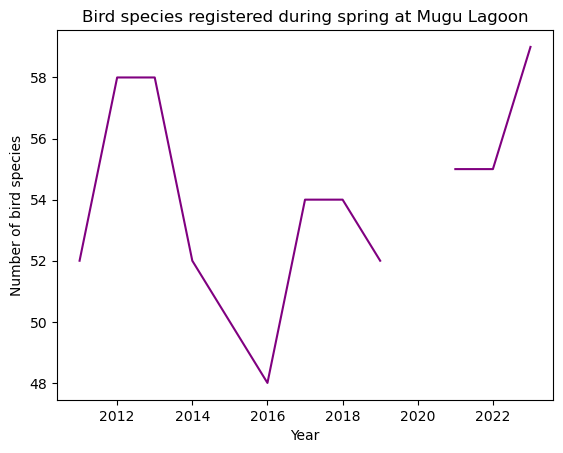

In [5]:
df.plot(
    x='year',
    y='MUL_spring',
    title='Bird species registered during spring at Mugu Lagoon',
    xlabel='Year',
    ylabel='Number of bird species',
    color='purple',
    legend=False
)

Check-in 2:
Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey. 

In [6]:
df.isna()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,False,False,False,False,False,True,False,True,False,False,True,True,False
1,False,False,False,True,False,False,True,False,False,True,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
# Here we are selecting a single column by its column name, which is an example of label-based subsetting. 
# `df.loc[]` uses square brackets because we are indexing to a certain point in the data that already exists. 
df.loc[df['MUL_spring'].isna()]

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
10,2020,46.0,NaN,47.0,56.0,NaN,66.0,57.0,NaN,58.0,54.0,40.0,54.0


To plot multiple lines, we need to update these parameters in the plot() method: 
`y`: a list of column names that will be plotted against the x-axis
`color`: a dictionary `{'column_1' : 'color_1', 'column_2': 'color_2'}` specifiying the color of each column's line plot

<Axes: title={'center': 'Seasonal bird surveys at Tijuana Estuary'}, xlabel='Year', ylabel='Number of bird species'>

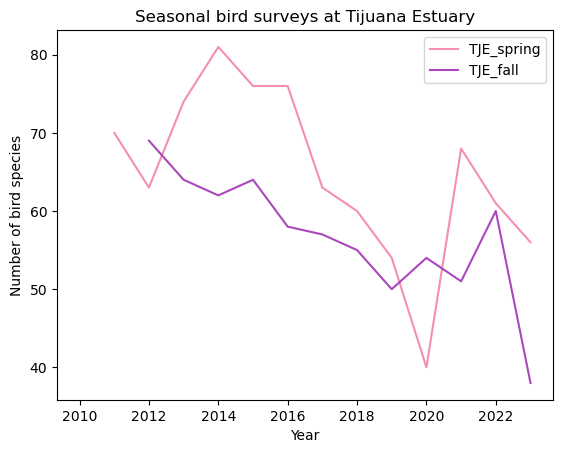

In [8]:
# Comparing bird surveys at the Tijuana Estuary during spring and fall across years
df.plot(x='year',
       y=['TJE_spring', 'TJE_fall'],
       title='Seasonal bird surveys at Tijuana Estuary',
       xlabel='Year', 
       ylabel='Number of bird species',
       color={'TJE_spring':'#F48FB1',
             'TJE_fall':'#AB47BC'
             }
       )

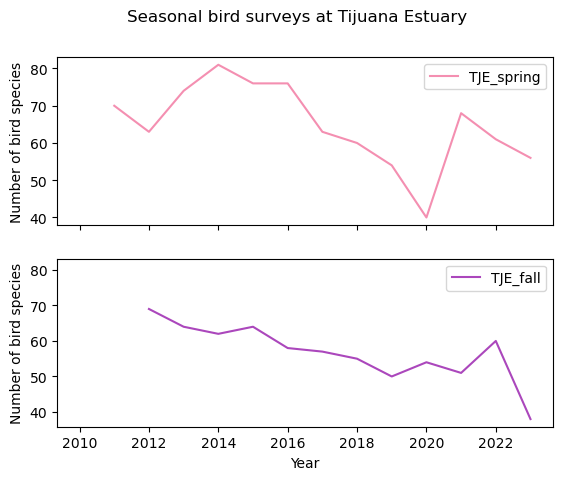

In [9]:
# Create separate plots for each column
df.plot(x='year',
       y=['TJE_spring', 'TJE_fall'],
       title='Seasonal bird surveys at Tijuana Estuary',
       xlabel='Year',
       ylabel='Number of bird species',
       color={'TJE_spring':'#F48FB1',
             'TJE_fall':'#AB47BC'
             },
       subplots=True
       );
# The `;` at the end suppresses the text output of the plot() method, which is otherwise printed above the graph.

**UPDATING THE INDEX**

Updating the index of our dataframe to be something other than the default integers numbering the rows (e.g. 0, 1, 2, etc.) can be a useful operation for plotting. To update the index we use the set_index() method for a `pandas.DataFrame`. 

It's general syntax is:
`df = df.set_index(new_index)`
where `new_index` is the name of the column in the dataframe `df` we want to use as new index.

Set `column_name` column in df as the new index (reassignment)
`df = df.set_index('column_name')`

In [10]:
# Update index to be the year column
df = df.set_index('year')
df.head()

,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
year,,,,,,,,,,,,
2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


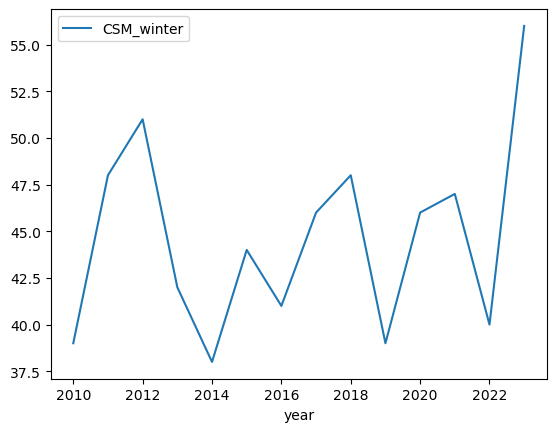

In [11]:
# Simple plot of Carpinteria Salt Marsh winter surveys
df.plot(y='CSM_winter');

In [12]:
# If needed, we can reset the index to be the numbering of the rows:
df = df.reset_index()

Check-in 1:
Without running the code, give a step-by-step breakdown of what this code is doing:
`df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()`

This line of code makes a line plot of all the variables from SDW_winter through TJE_fall, with year on the x-axis. 
Take my DataFrame → make year the index → select all rows and the columns from SDW_winter through TJE_fall → plot those columns against year.

Because year is now the index, pandas will generally use year for the x-axis.

*Using the :*
: before the comma → select all rows
'SDW_winter':'TJE_fall' after the comma → select the columns from SDW_winter through TJE_fall

Check-in 2: 
Is this code modifying the dataframe `df`? Why or why not?

No, this code does not modify the original data frame. 
1. df.set_index('year') creates a new DataFrame where year is the index.
2. .loc[...] selects certain rows and columns from that new DataFrame.
3. .plot() creates a plot from the selected data.
4. Nothing gets assigned back to df, so the original df stays unchanged.

Check-in 3: 
Run the code and examine the graph. Review the data description. Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?

Do we know how the different sites recorded their data? If it was not all recorded in the same way, then it may not make sense to directly compare the surveys. Also, there are some NA values in the SDW_spring. 

<Axes: xlabel='year'>

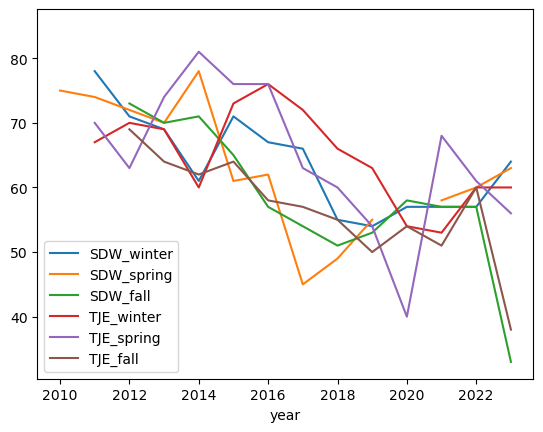

In [13]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

**METHOD CHAINING**

`df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()` is an example of method chaining. Each method in the chain returns a new object(usually a pandas.DataFrame or a pandas.Series), allowing the next method to be called directly on the result. 

Parentheses can break up method chaining:
`(df.set_index('year')
    .loc[:,'SDW_winter':'TJE_fall']
    .plot()
 )`

NOTE: The period `.` in the method chaining plays a similar role to the R pipe operator. But they are not the same. The R pipe operator passes the result on the left as the first argumment of any function, while the period can only call methods that belong to the object on the left. 

**DATA EXPLORATION WITH PENGUIN DATA**

In [14]:
# Read in data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Get some preliminary information about the data:

In [15]:
# Check column data types and NA values
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [16]:
# Simple statistics about numeric columns
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


Subset the data frame to get information about a particular column or groups of columns:

In [17]:
# Count unique values in categorical columns and year
penguins[['species', 'island','sex','year']].nunique()

species    3
island     3
sex        2
year       3
dtype: int64

In [18]:
# Get unique values in species column
penguins['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [19]:
# Number of values per unique value in species column
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

**`KIND` ARGUMENT IN `PLOT()`**
`plot()` method creates a line plot by default, the `kind` parameter controls this behavior. By changing the value of `kind` we can create different kinds of plots. 

Let's change the `kind` parameter to create some different plots: 

**SCATTER PLOTS**

To visually compare the flipper length against the body mass:

<Axes: title={'center': 'Flipper length and body mass for Palmer penguins'}, xlabel='Flipper length (mm)', ylabel='Body mass (g)'>

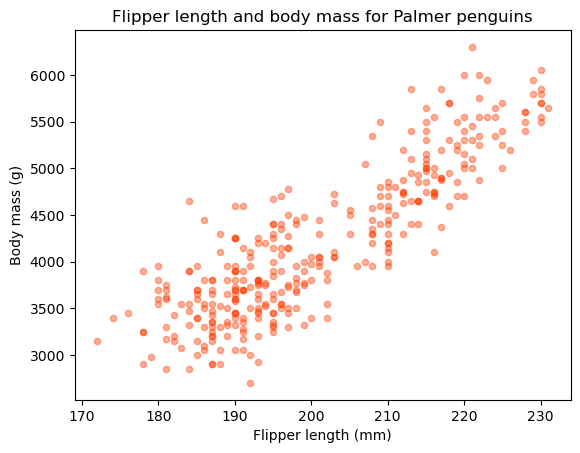

In [20]:
penguins.plot(kind='scatter',
             x='flipper_length_mm',
             y='body_mass_g',
             title='Flipper length and body mass for Palmer penguins',
             xlabel='Flipper length (mm)',
             ylabel='Body mass (g)',
             color='#ff3b01',
             alpha=0.4 # Controls transparency
             )

**BAR PLOTS**

If we want to get data about the 10 penguins with the lowest body mass.

In [21]:
smallest = penguins['body_mass_g'].nsmallest(10)
smallest

314    2700.0
58     2850.0
64     2850.0
54     2900.0
98     2900.0
116    2900.0
298    2900.0
104    2925.0
47     2975.0
44     3000.0
Name: body_mass_g, dtype: float64

<Axes: >

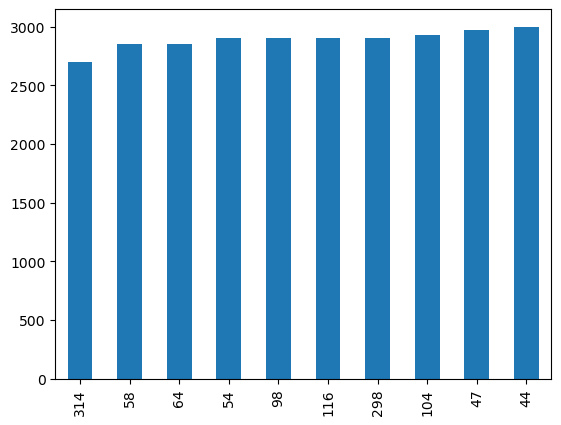

In [22]:
smallest.plot(kind='bar')

In [23]:
# If we wanted to look at other data for these smallest penguins we can do:
penguins.nsmallest(10, 'body_mass_g')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,female,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,female,2009
298,Chinstrap,Dream,43.2,16.6,187.0,2900.0,female,2007
104,Adelie,Biscoe,37.9,18.6,193.0,2925.0,female,2009
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
44,Adelie,Dream,37.0,16.9,185.0,3000.0,female,2007


**HISTOGRAMS**

<Axes: ylabel='Frequency'>

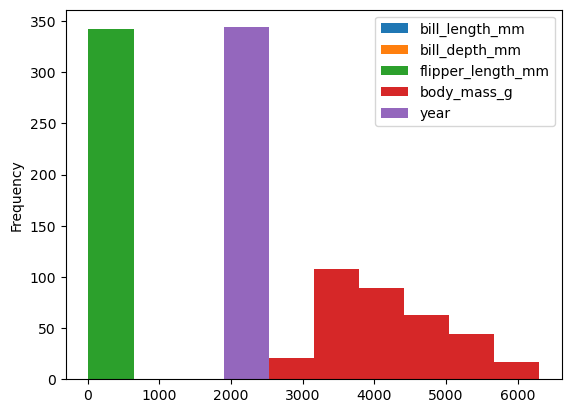

In [24]:
# Using plot without subsetting data - a mess again
penguins.plot(kind='hist')

To gain actual information, let's **SUBSET** the data before plotting it. 

<Axes: title={'center': 'Penguin flipper lengths'}, xlabel='Flipper length (mm)', ylabel='Frequency'>

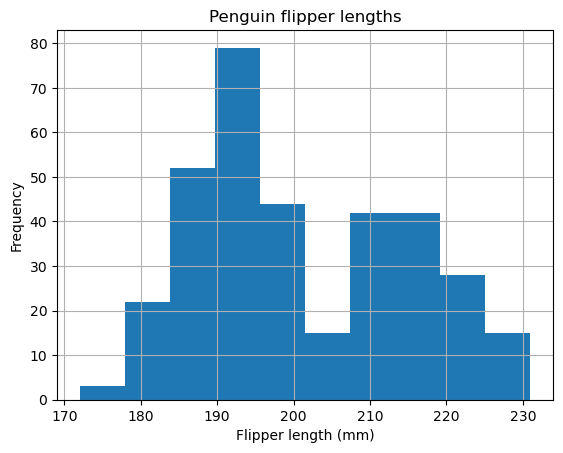

In [25]:
# Distribution of flipper length measurements
# First select data, then plot
penguins['flipper_length_mm'].plot(kind='hist',
                                  title='Penguin flipper lengths', 
                                  xlabel='Flipper length (mm)',
                                  grid=True)

Check-in 1: 
Select the `bill_length_mm` and the `bill_depth_mm` columns in the `penguins` data frame and then update the `kind` parameter to `box` to make boxplots of the bill length and bill depth. 

<Axes: title={'center': 'Penguin bill lengths'}>

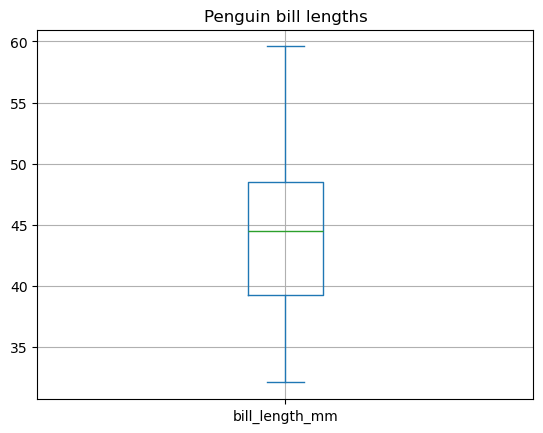

In [26]:
penguins['bill_length_mm'].plot(kind='box',
                               title='Penguin bill lengths',
                               grid=True)

<Axes: title={'center': 'Penguin bill depths'}>

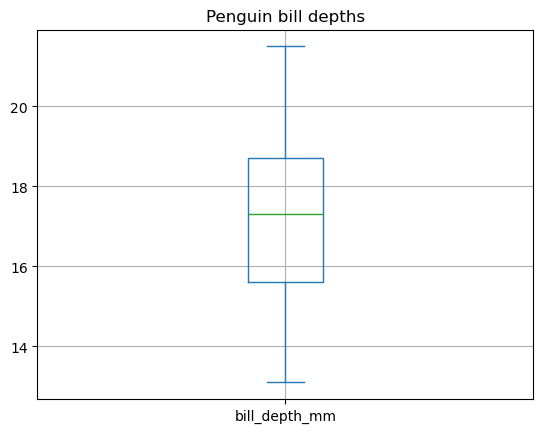

In [27]:
penguins['bill_depth_mm'].plot(kind='box',
                               title='Penguin bill depths',
                               grid=True)

Check-in 2: 
Create a simple histogram of the flipper length of female gentoo penguins. 

<Axes: title={'center': 'Flipper length of female Gentoo penguins'}, xlabel='Flipper length (mm)', ylabel='Frequency'>

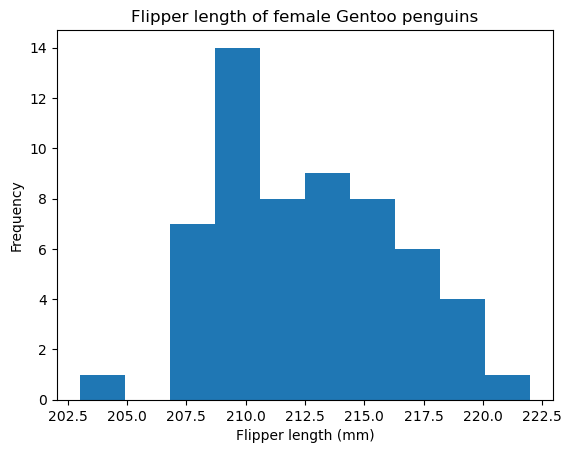

In [28]:
penguins[(penguins['species'] == 'Gentoo') & (penguins['sex'] == 'female')]['flipper_length_mm'].plot(kind='hist',
                                                                                                     title='Flipper length of female Gentoo penguins',
                                                                                                     xlabel='Flipper length (mm)')